Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from unet_lstm import unet_lstm
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

D:\ppg_project/code/model_build/my_tool/tool/data_load\ppg_labeled_load.py:89: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC"],"Group": True})


Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_12272\2803335453.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})


254
torch.Size([1, 800])


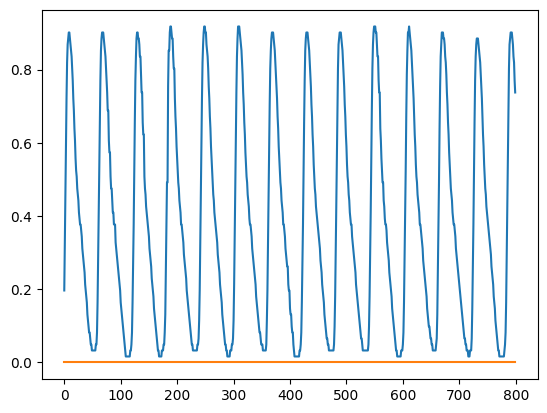

In [2]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {    "Serie length":         800,
            "Input size":           50,
            "Hidden size":          20, # changed hidden size to match with the struct
            "Number layers":        5,
            "Encoder structure":    [1,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,50],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Down kernel":          [8,8,8,8],
            "Up kernel":            [4,4,4,4],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model = unet_lstm(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=100,batch=64,visualize=1)

True
Iteration: 1/1500. loss_train: 0.10061854124069214. loss_val: 0
Iteration: 2/1500. loss_train: 0.09904128313064575. loss_val: 0
Iteration: 3/1500. loss_train: 0.0976431593298912. loss_val: 0
Iteration: 4/1500. loss_train: 0.09596678614616394. loss_val: 0
Iteration: 5/1500. loss_train: 0.09448378533124924. loss_val: 0
Iteration: 6/1500. loss_train: 0.09313122183084488. loss_val: 0
Iteration: 7/1500. loss_train: 0.0916299819946289. loss_val: 0
Iteration: 8/1500. loss_train: 0.09020794183015823. loss_val: 0
Iteration: 9/1500. loss_train: 0.088783398270607. loss_val: 0
Iteration: 10/1500. loss_train: 0.08735616505146027. loss_val: 0
Iteration: 11/1500. loss_train: 0.08581022918224335. loss_val: 0
Iteration: 12/1500. loss_train: 0.08441753685474396. loss_val: 0
Iteration: 13/1500. loss_train: 0.08297528326511383. loss_val: 0
Iteration: 14/1500. loss_train: 0.08168095350265503. loss_val: 0
Iteration: 15/1500. loss_train: 0.08015314489603043. loss_val: 0
Iteration: 16/1500. loss_train: 0

KeyboardInterrupt: 

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_12272\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  0.99992263
Mean loss:  0.37246072
Min loss:  7.736859e-05
Number of test:  84


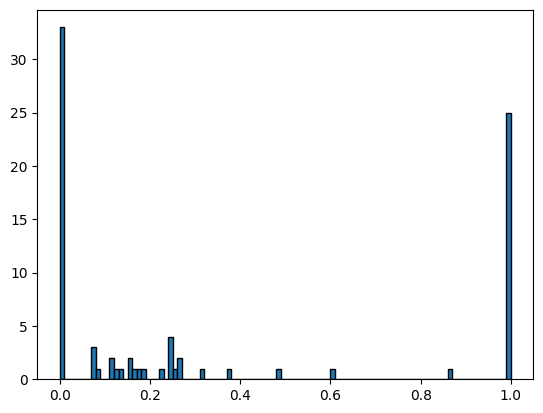

0.15755557


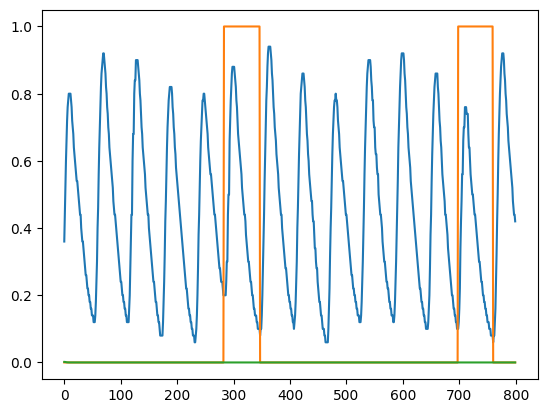

0.99992263


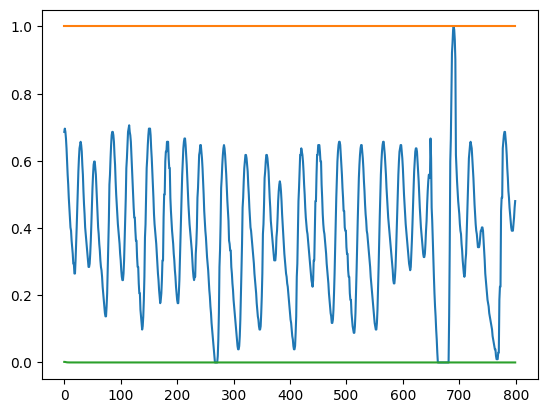

0.99992263


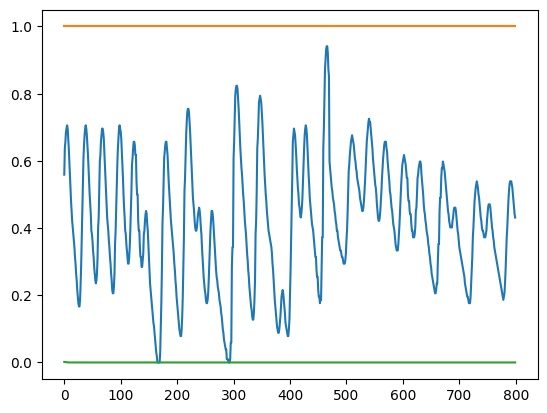

7.737079e-05


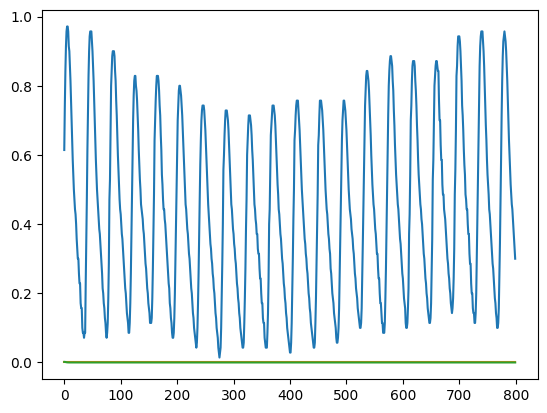

7.7370656e-05


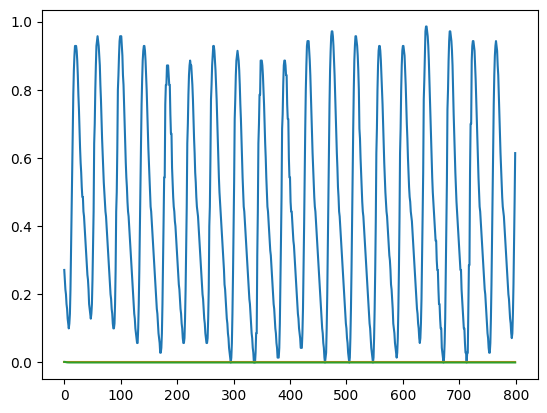

7.737085e-05


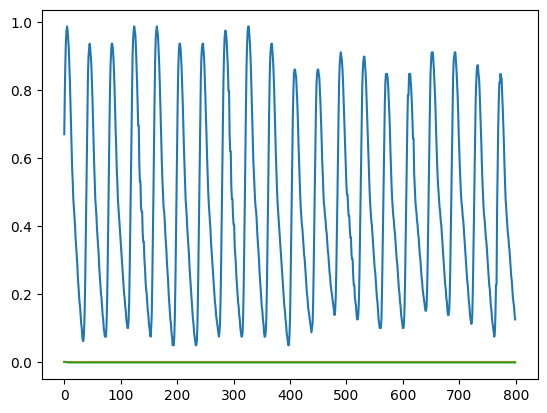

7.73705e-05


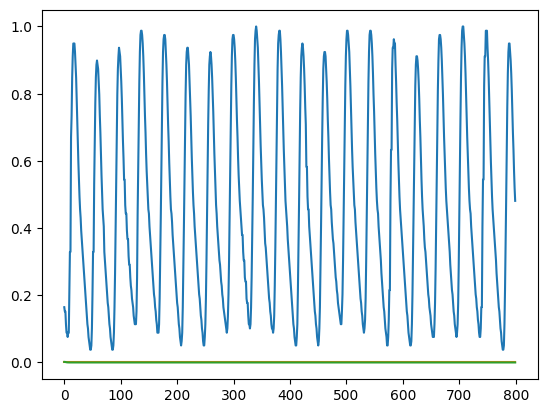

7.736969e-05


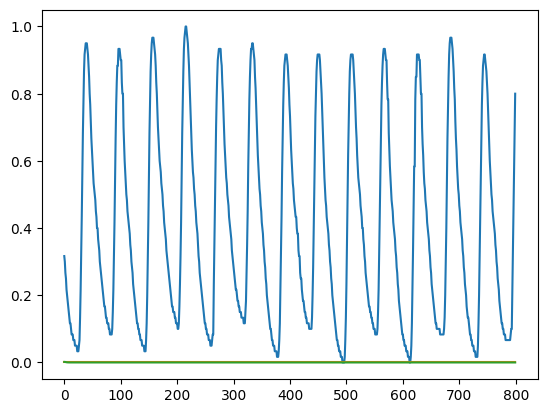

7.736984e-05


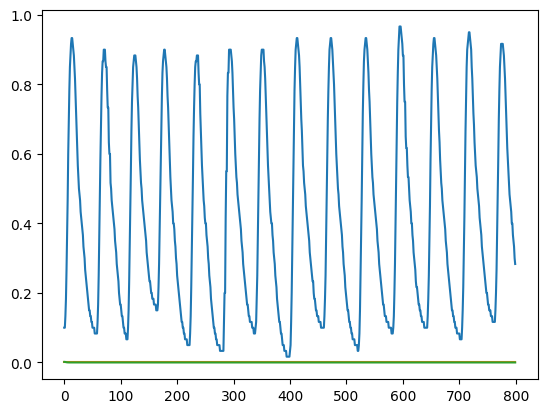

7.737066e-05


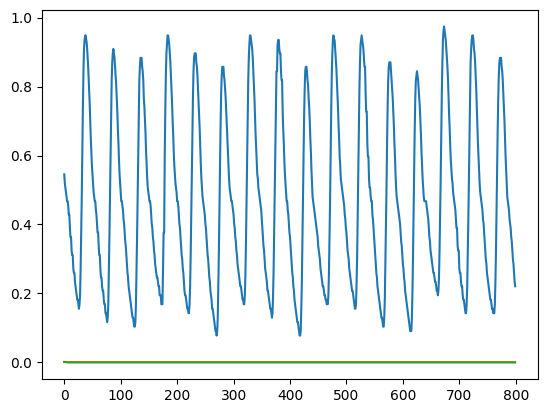

7.737027e-05


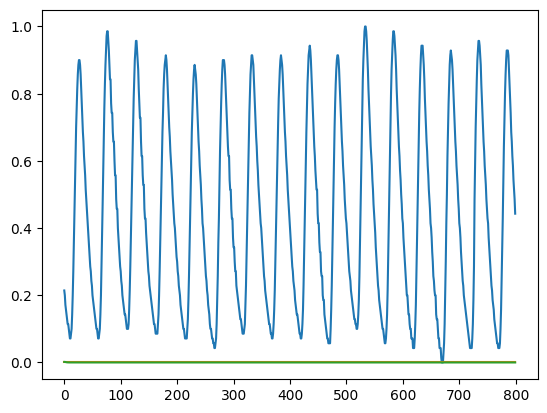

7.737107e-05


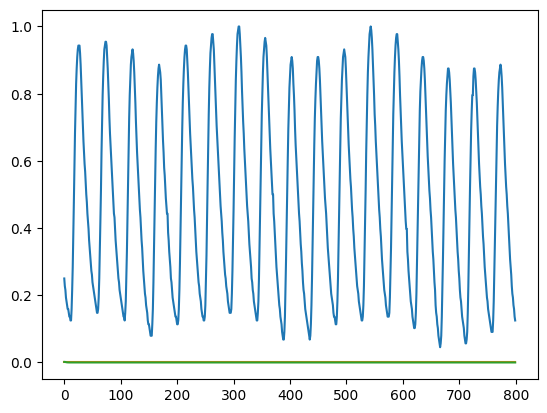

0.18005244


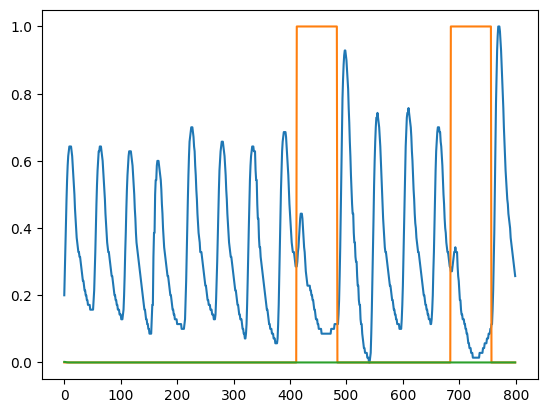

7.736859e-05


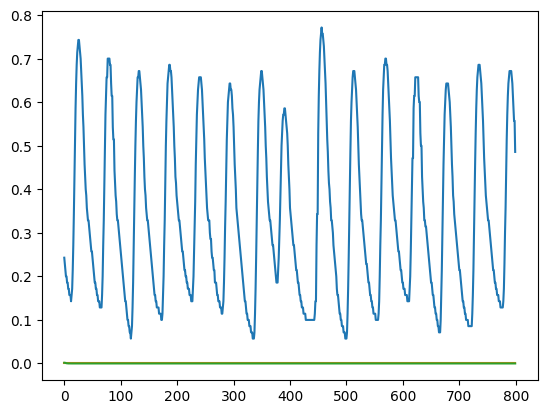

0.07630044


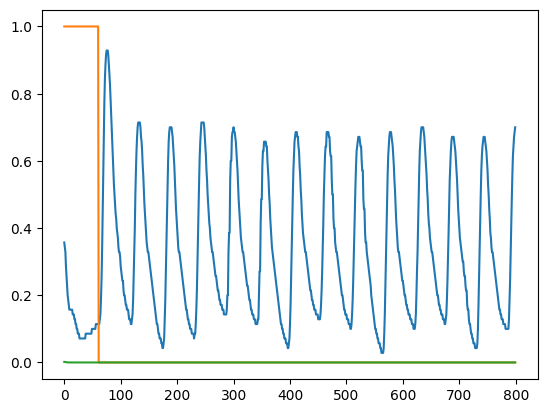

7.736874e-05


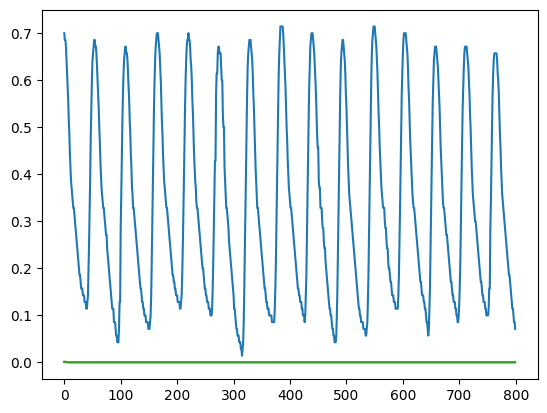

0.9986769


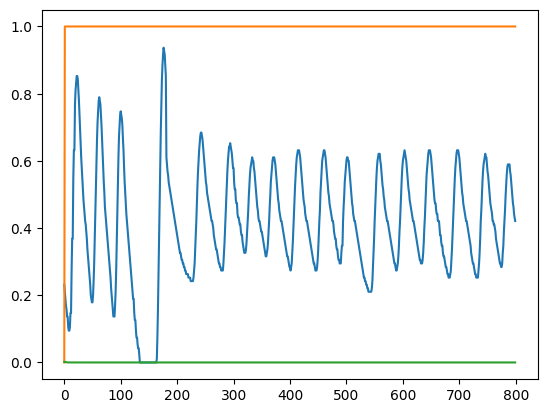

0.99992263


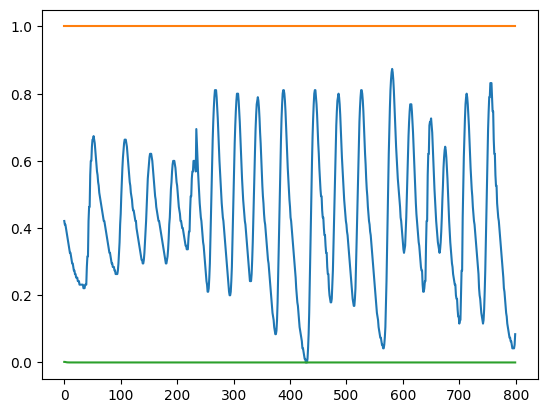

0.99992263


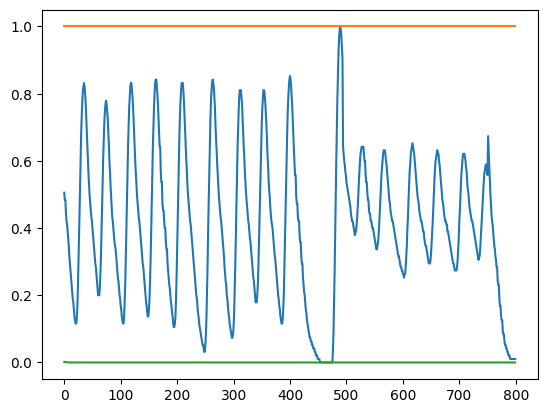

0.99992263


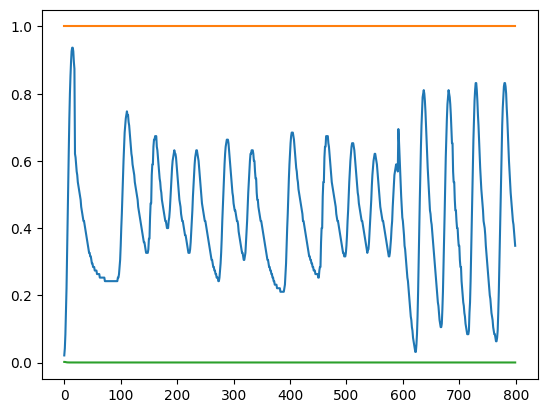

0.99992263


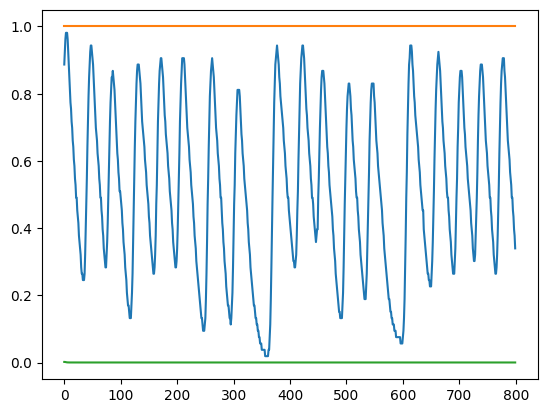

7.736969e-05


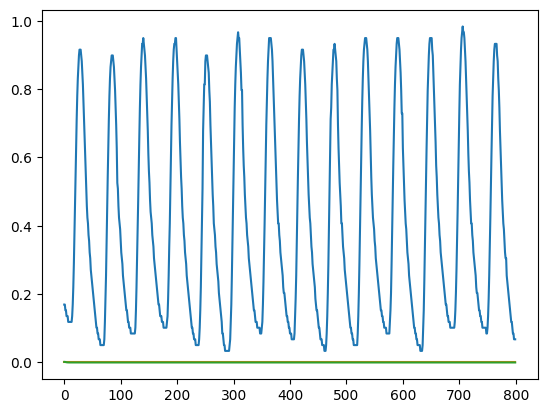

7.7369805e-05


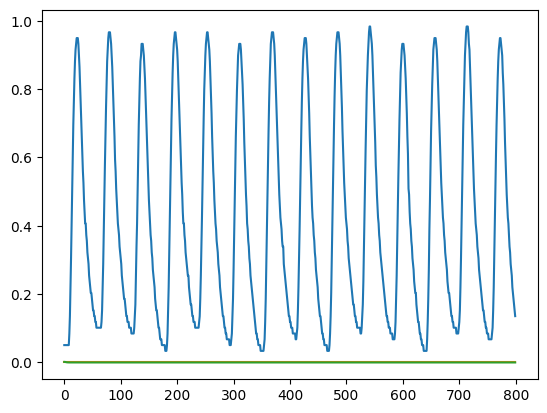

7.737093e-05


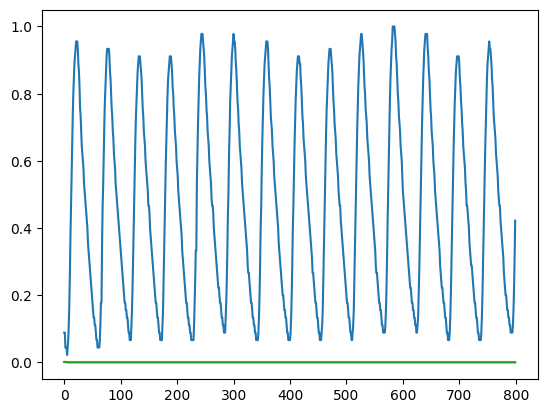

7.7370096e-05


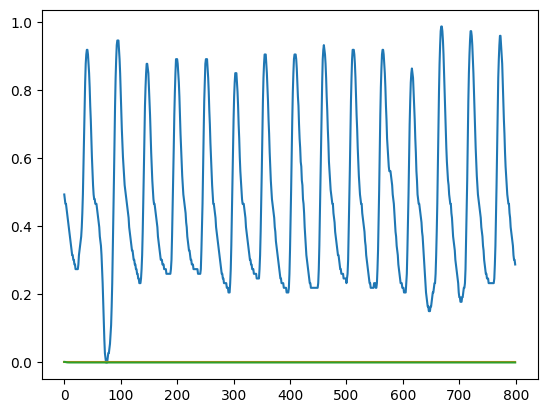

7.7368975e-05


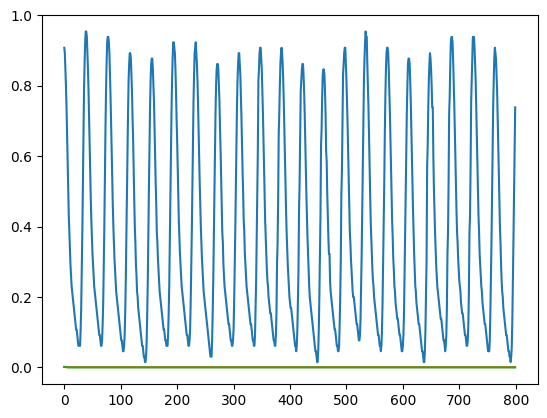

0.99992263


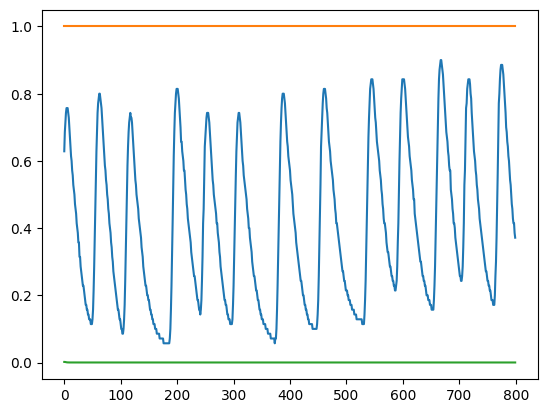

7.737058e-05


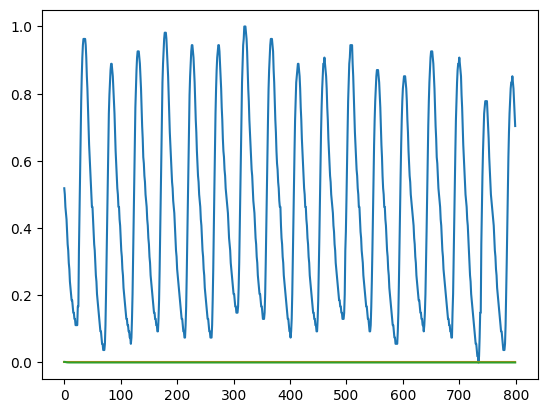

7.73707e-05


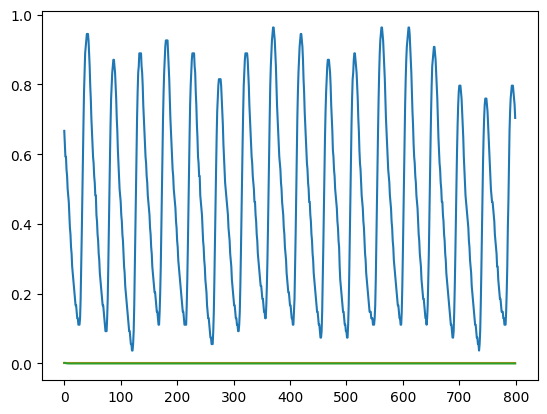

0.8687071


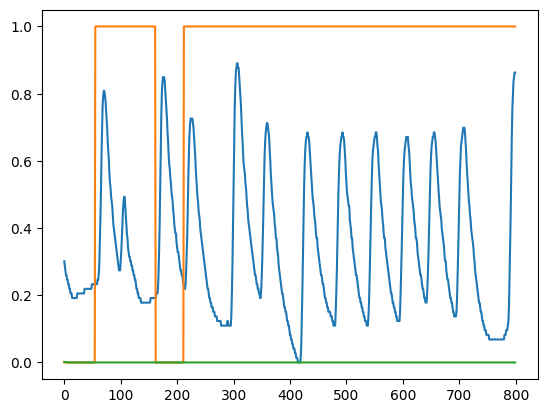

7.7370285e-05


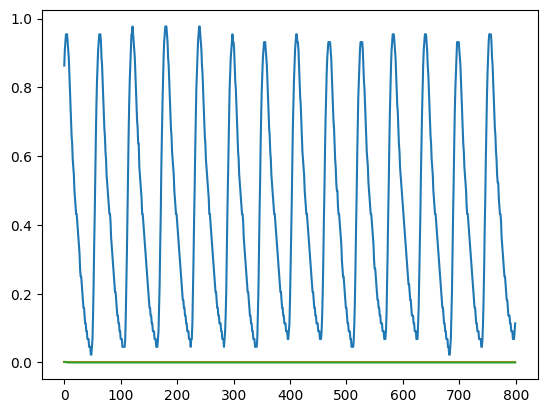

7.736947e-05


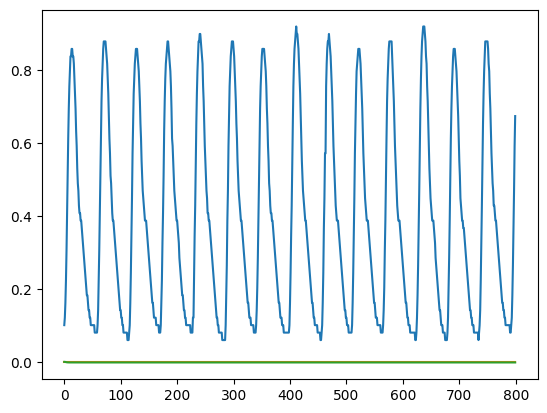

7.7370954e-05


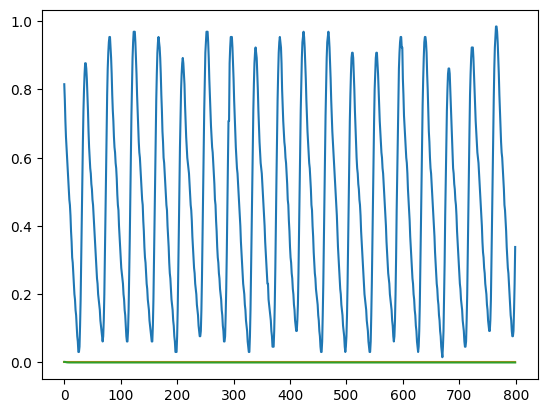

7.737056e-05


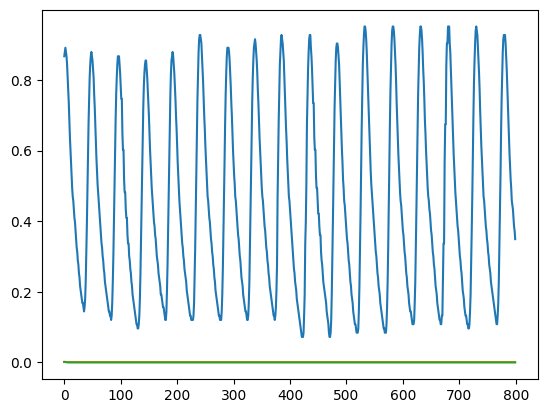

7.737035e-05


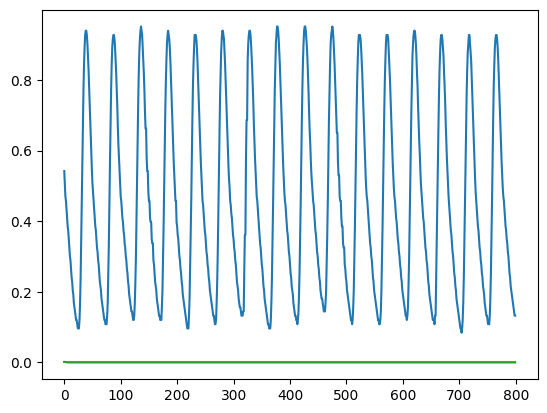

7.737084e-05


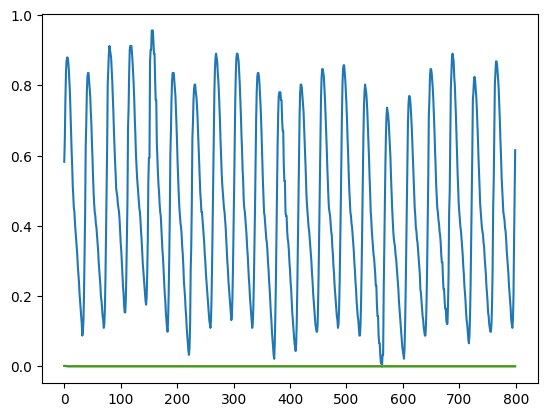

7.737018e-05


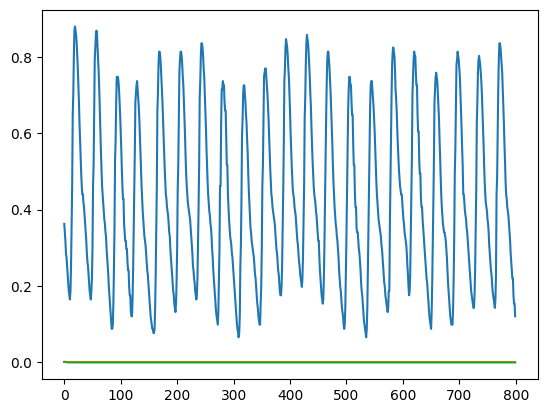

7.737058e-05


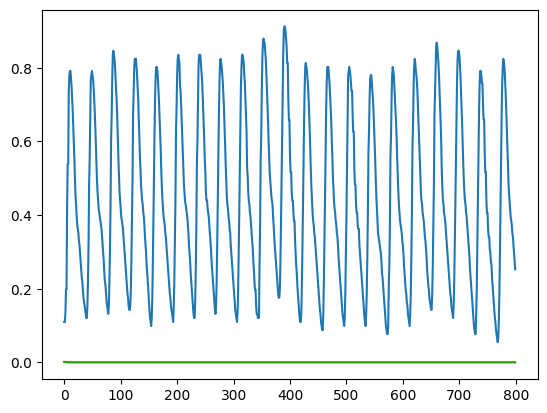

7.736999e-05


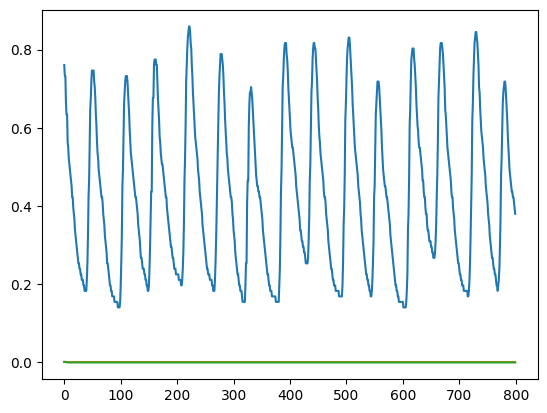

0.9986769


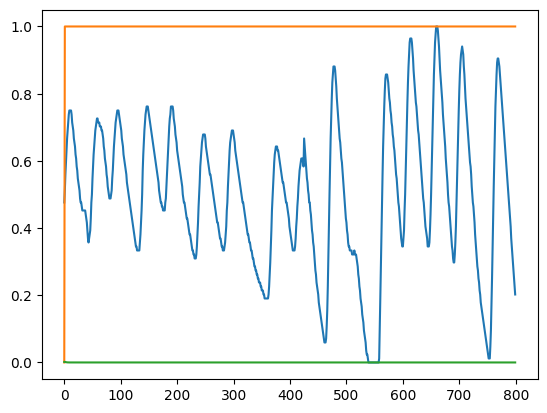

7.7370336e-05


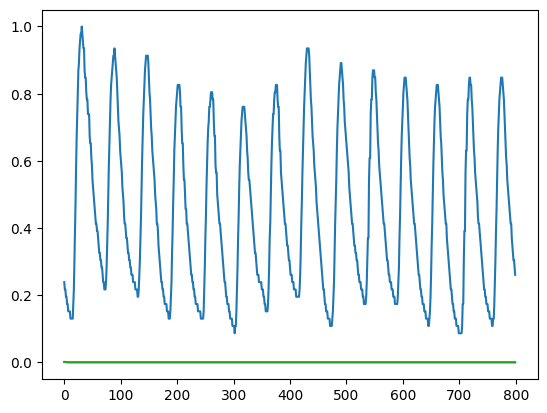

0.99992263


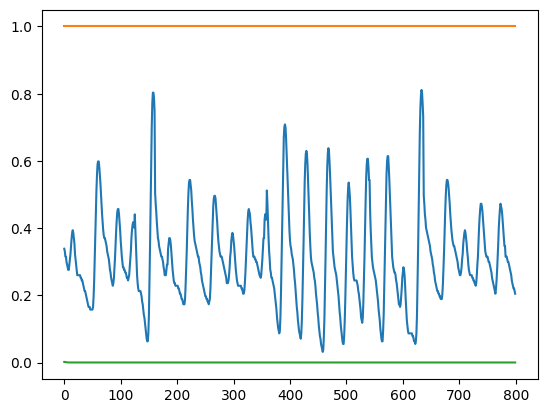

0.99992263


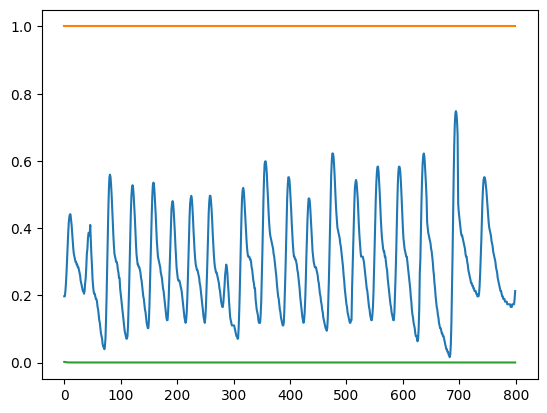

7.736873e-05


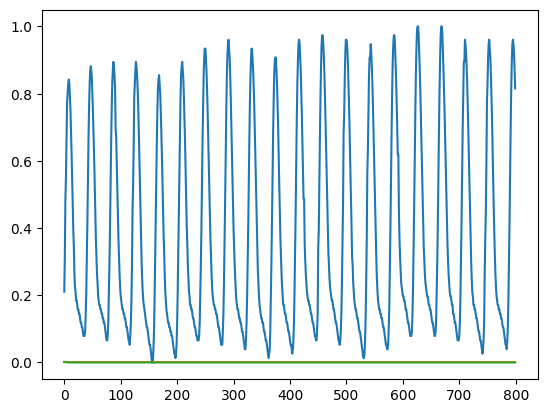

0.13255903


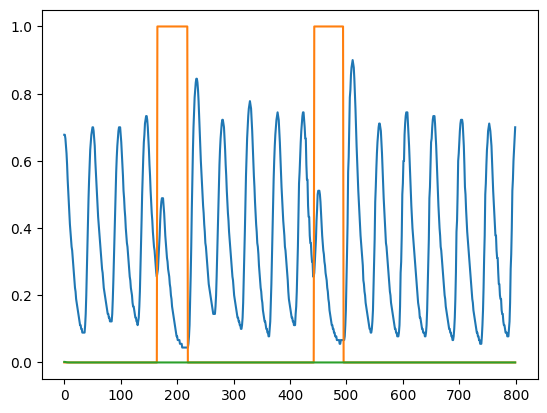

0.07756664


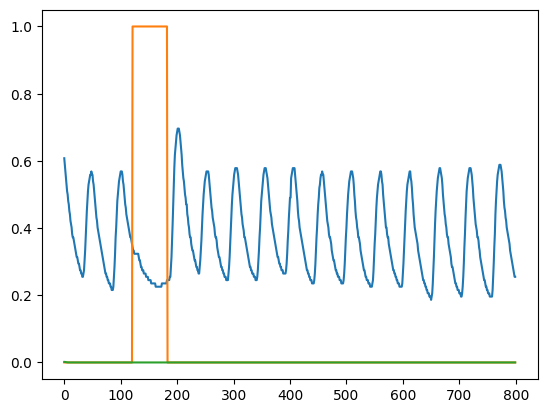

0.08381578


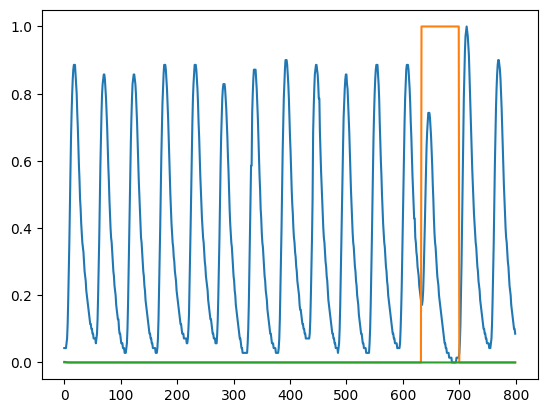

0.99992263


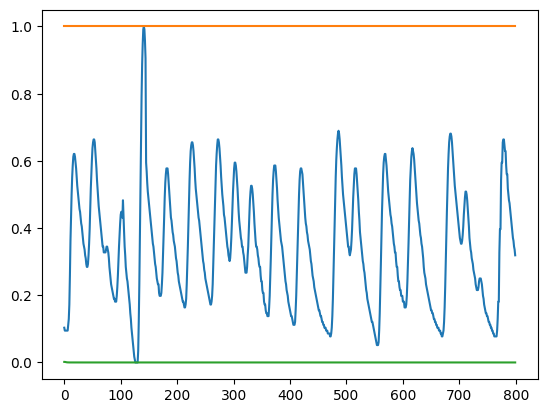

0.99992263


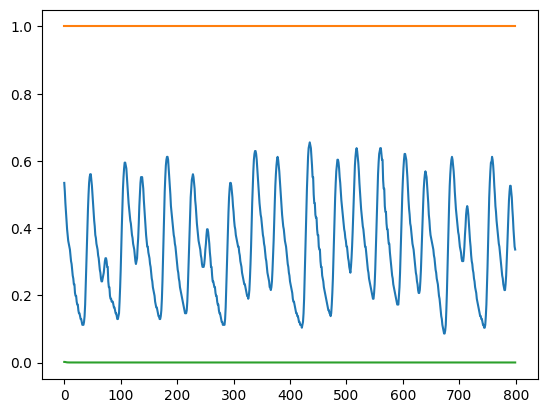

0.2412938


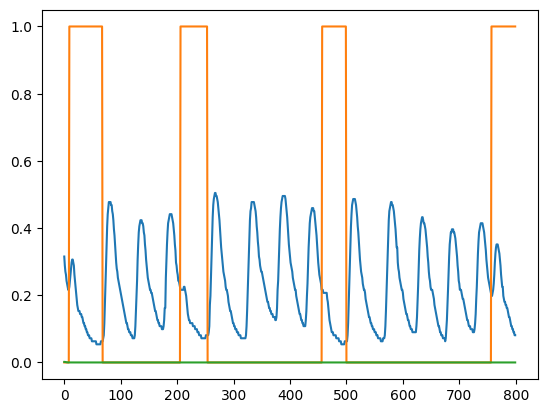

0.26002502


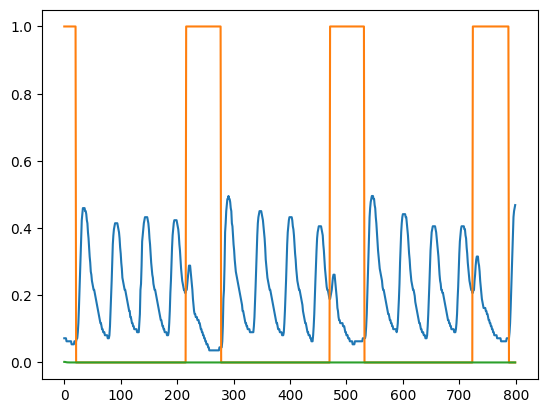

0.17255348


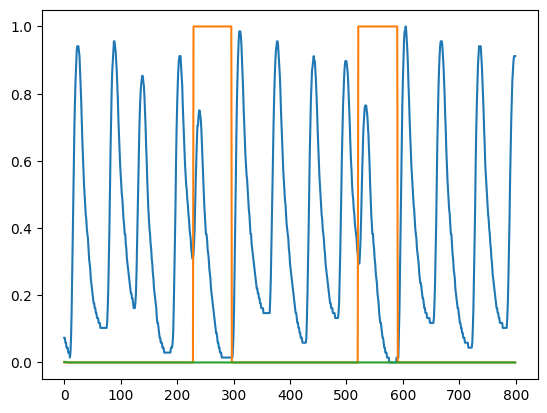

7.736921e-05


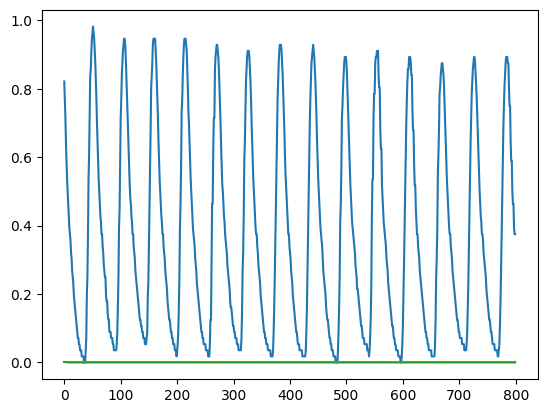

7.737054e-05


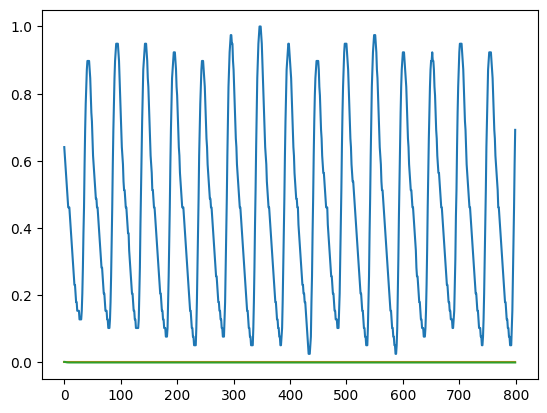

7.737053e-05


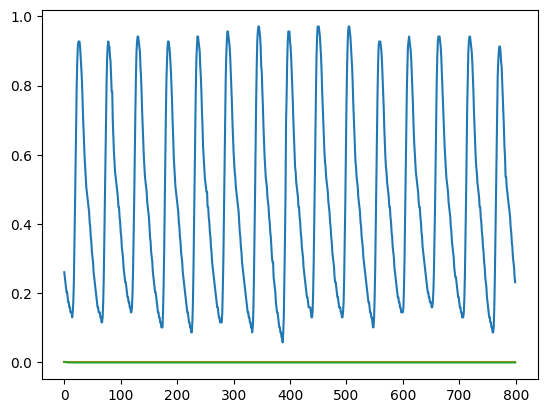

0.99992263


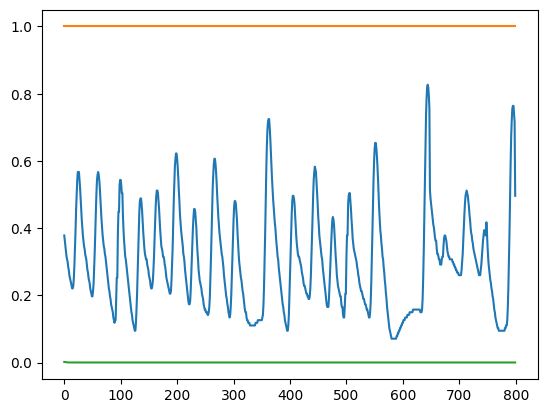

0.99992263


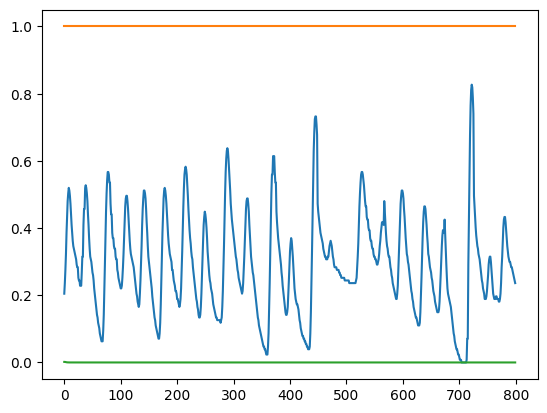

0.07381716


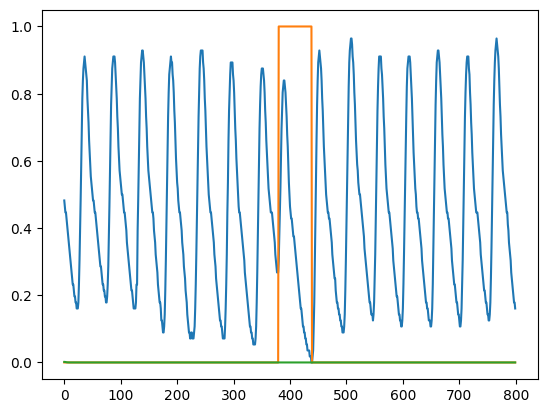

0.99992263


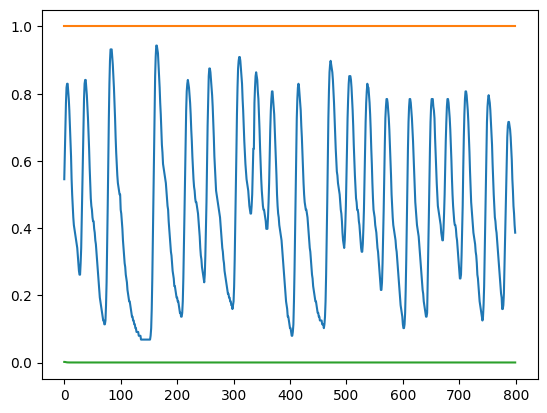

0.99992263


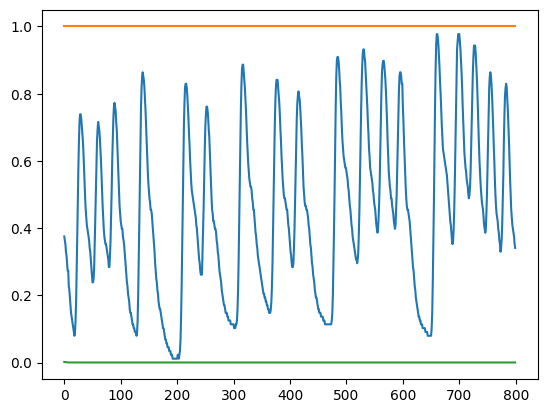

0.99992263


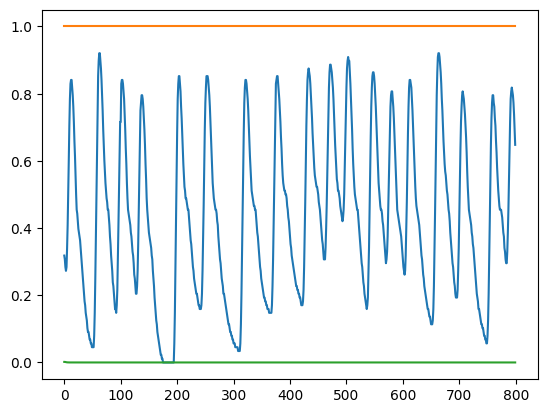

0.31878325


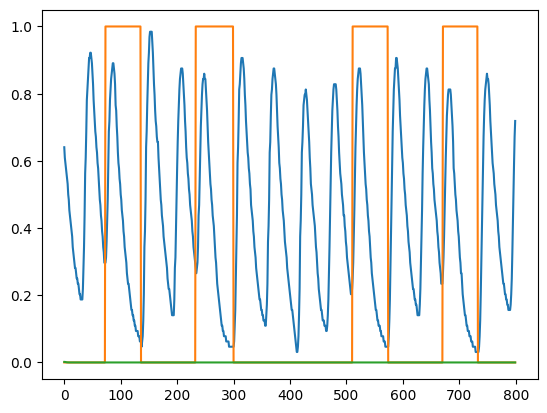

0.4875099


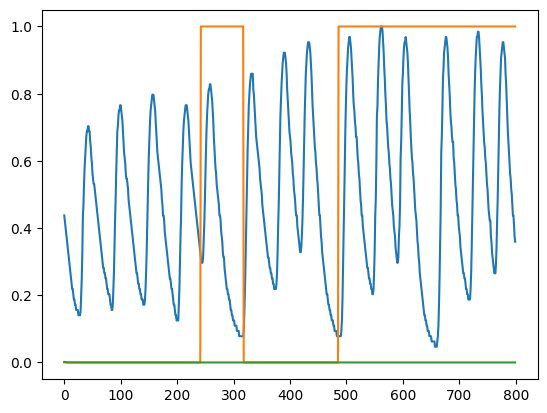

0.16005524


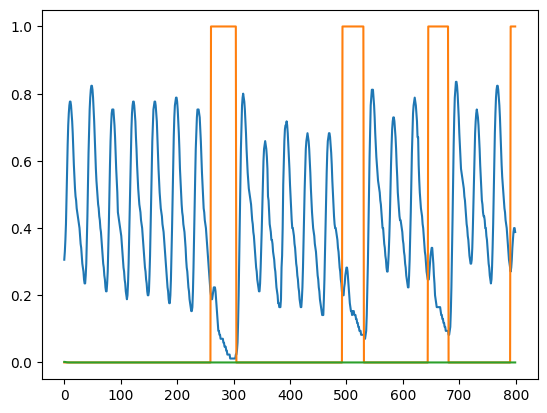

0.2600414


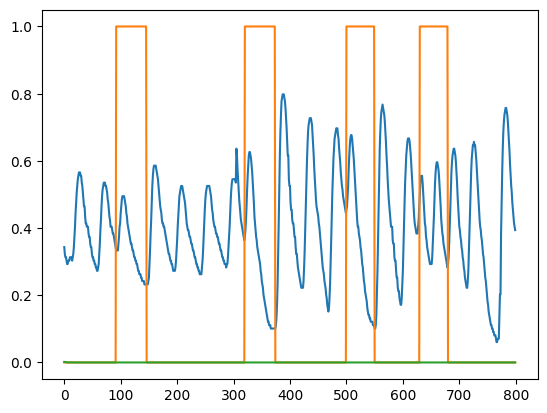

7.737075e-05


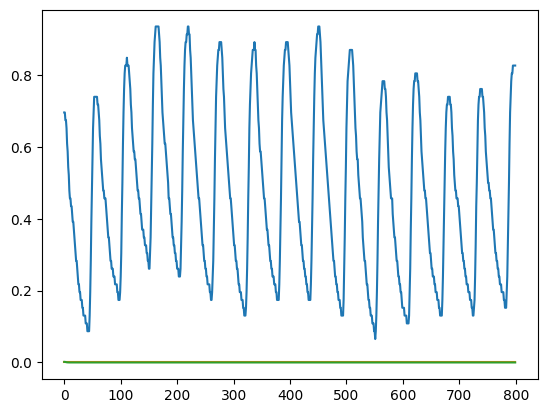

0.99992263


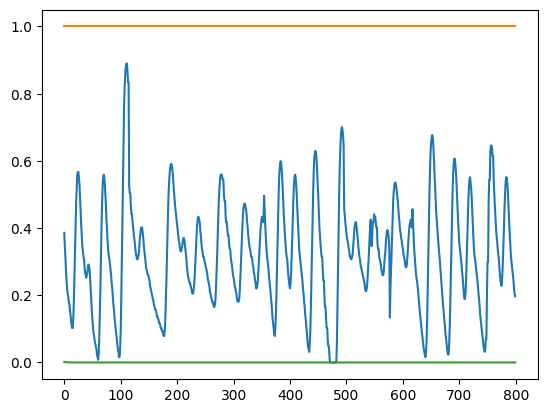

0.24879295


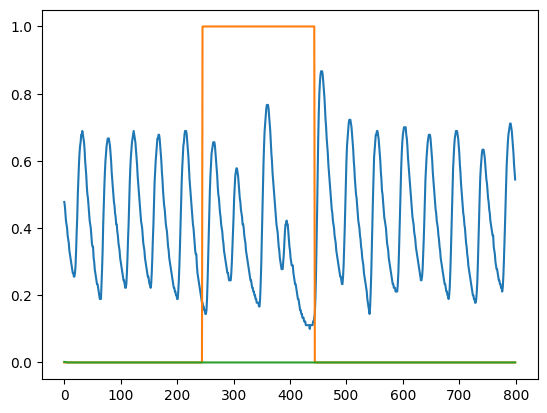

0.38000837


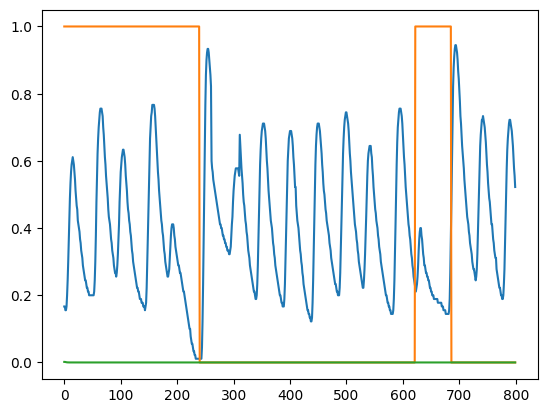

0.22879569


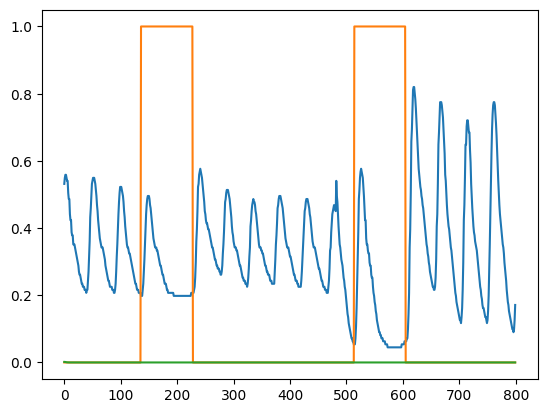

0.24129398


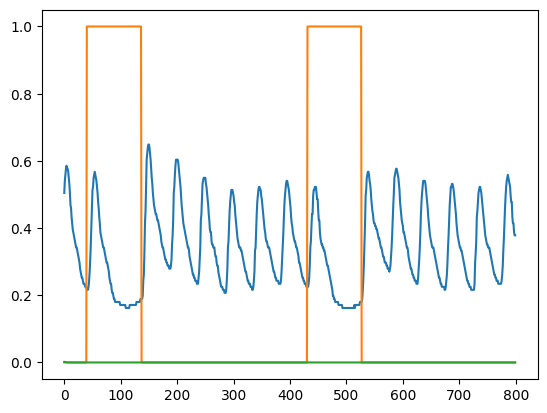

0.24004413


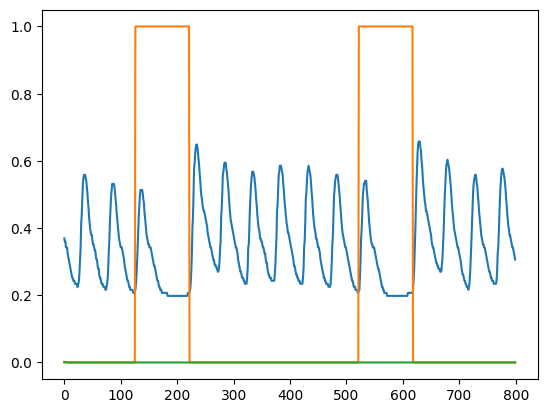

0.11881094


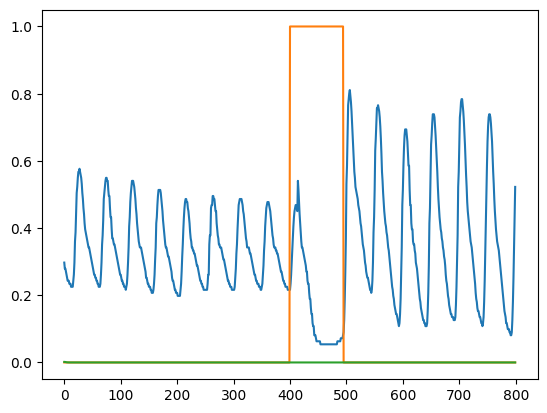

0.11881094


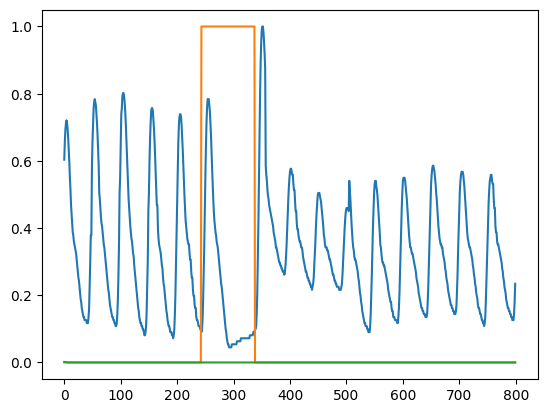

0.99992263


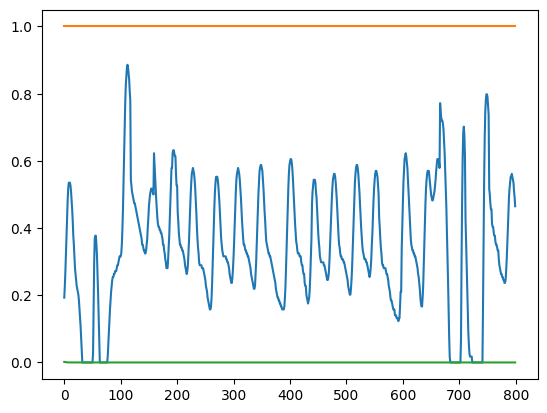

0.99992263


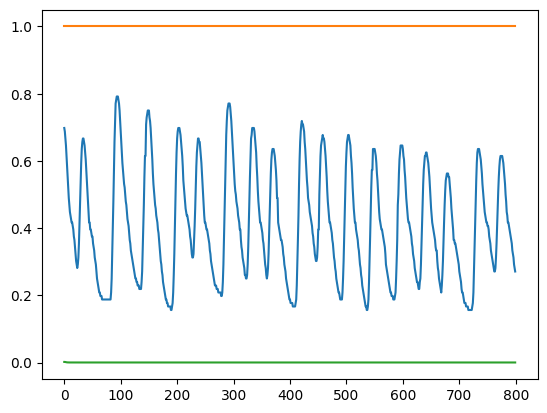

0.99992263


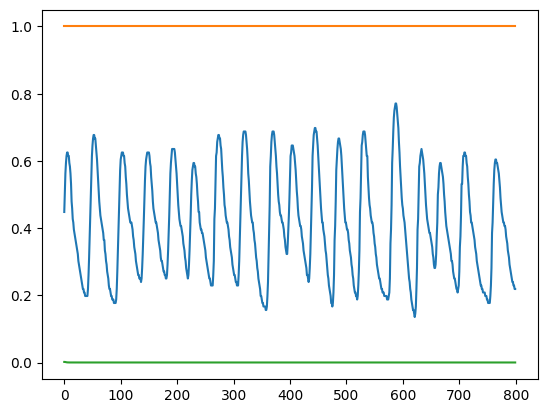

0.99992263


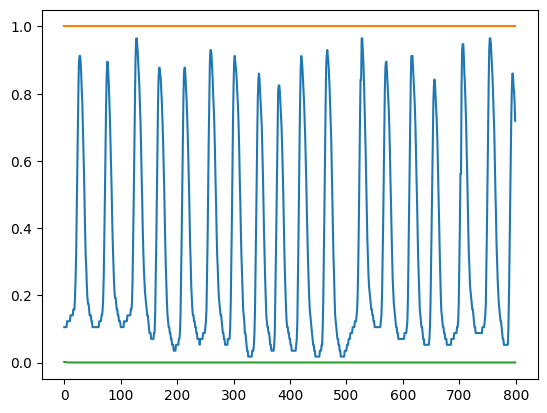

0.60747695


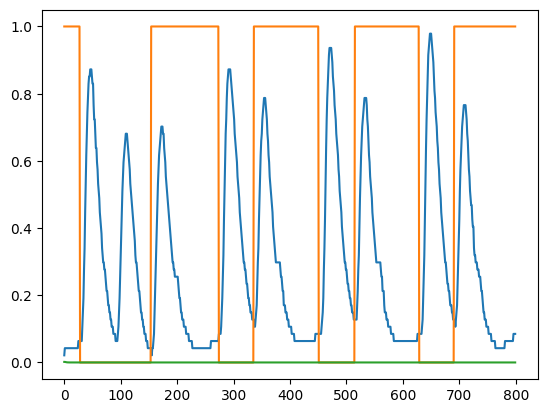

0.1588054


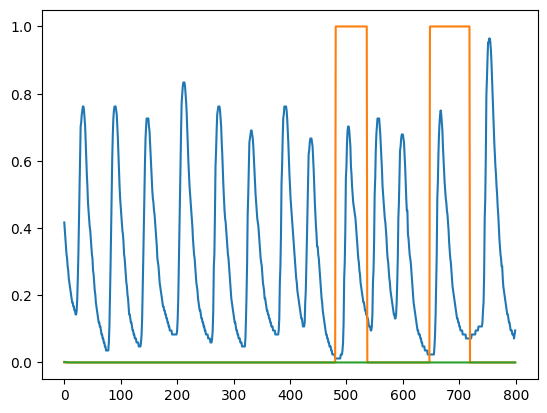

0.99992263


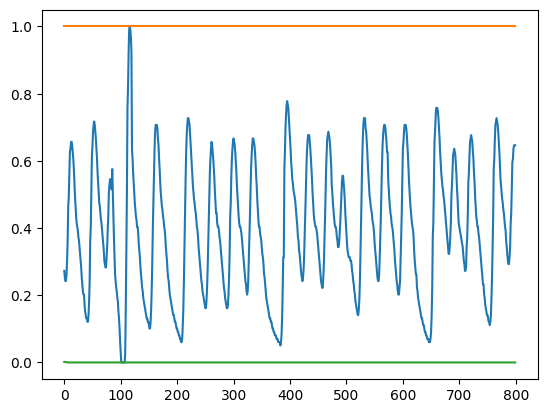

0.99992263


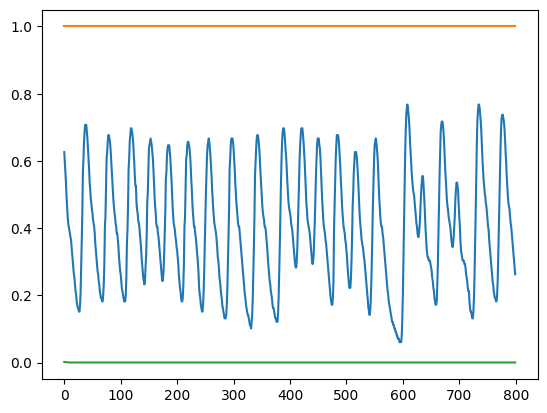

0.1263099


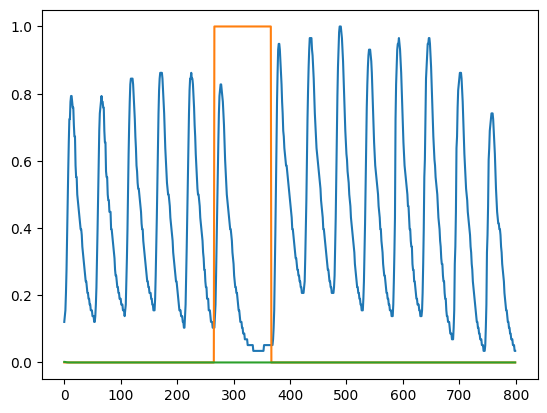

0.26879016


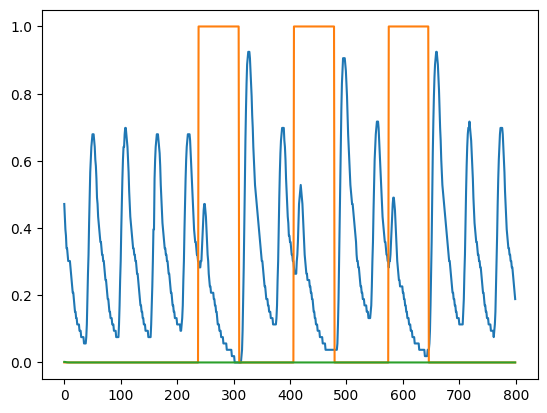

In [4]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()